Mean phase difference: -3.9500696838404323 degrees


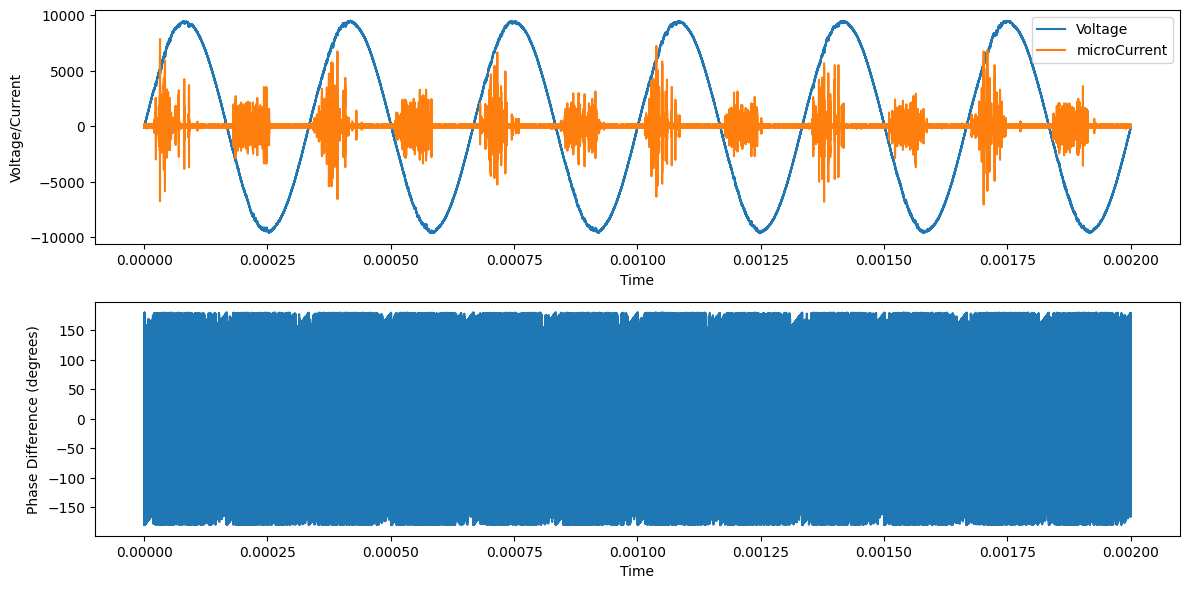

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Load the data
data = pd.read_csv(r'C:\Users\sbossier\Desktop\20230707-0001.csv')

# Compute the time derivative of the charge to get the current
data['Current'] = np.gradient(data['Charge'], data['Time'])

# Use the Hilbert transform to get the analytical signal for voltage and current
voltage_analytic = hilbert(data['Voltage'])
current_analytic = hilbert(data['Current'])

# Compute the instantaneous phase of voltage and current
voltage_phase = np.unwrap(np.angle(voltage_analytic))
current_phase = np.unwrap(np.angle(current_analytic))

# Compute the phase difference
phase_difference = voltage_phase - current_phase

# Correct phase difference to be within -pi to pi radians
phase_difference = (phase_difference + np.pi) % (2 * np.pi) - np.pi

# Print the mean phase difference in degrees
print('Mean phase difference:', np.mean(phase_difference) * 180 / np.pi, 'degrees')

# Plot voltage and current
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(data['Time'], data['Voltage'], label='Voltage')
plt.plot(data['Time'], data['Current']*1000000, label='microCurrent')
plt.xlabel('Time')
plt.ylabel('Voltage/Current')
plt.legend()

# Plot phase difference
plt.subplot(2, 1, 2)
plt.plot(data['Time'], phase_difference * 180 / np.pi)
plt.xlabel('Time')
plt.ylabel('Phase Difference (degrees)')

plt.tight_layout()
plt.show()

Mean phase difference: -43.24981197230329 degrees
Real power: 29.935632993381386 W
Reactive power: -64.25482908179838 VAR
Apparent power: 93.7779456677088 VA
Power factor: 0.31921826374246676
Power factor (cos): 0.7283732184451368


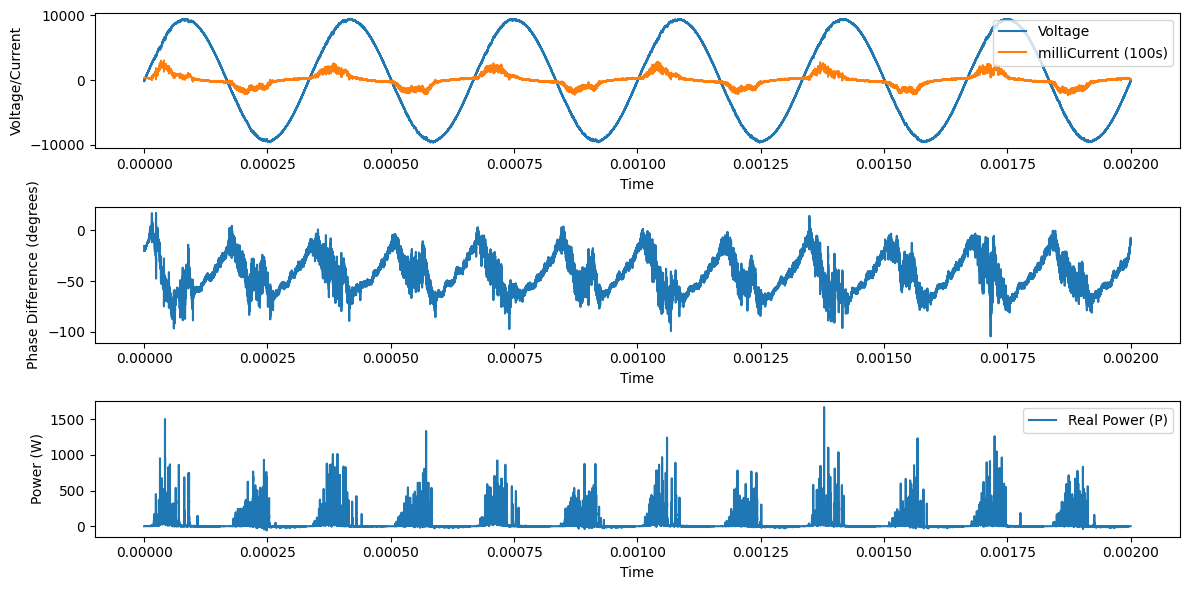

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.signal import savgol_filter

# Load the data
data = pd.read_csv(r'C:\Users\sbossier\Desktop\20230707-0001.csv')

# Apply a Savitzky-Golay filter to the 'Charge' data
window_size = 5001  # Window size should be odd and can be adjusted to suit your data
poly_order = 3  # Polynomial order can be adjusted to suit your data
data['Charge_smooth'] = savgol_filter(data['Charge'], window_size, poly_order)

# Compute the time derivative of the smoothed charge to get the current
data['Current_der'] = np.gradient(data['Charge_smooth'], data['Time'])

# Use the Hilbert transform to get the analytical signal for voltage and current
voltage_analytic = hilbert(data['Voltage'])
current_analytic = hilbert(data['Current_der'])

# Compute the instantaneous phase of voltage and current
voltage_phase = np.unwrap(np.angle(voltage_analytic))
current_phase = np.unwrap(np.angle(current_analytic))

# Compute the phase difference
phase_difference = voltage_phase - current_phase

# Correct phase difference to be within -pi to pi radians
phase_difference = (phase_difference + np.pi) % (2 * np.pi) - np.pi

# Compute the real power, reactive power, apparent power and power factor
# Compute the real power, reactive power, apparent power and power factor
Vrms = np.sqrt(np.mean(data['Voltage']**2))
Irms = np.sqrt(np.mean(data['Current']**2))
phase_difference_rad = np.mean(phase_difference)  # in radians

real_power = np.mean(data['Voltage'] * data['Current'])
reactive_power = Vrms * Irms * np.sin(phase_difference_rad)
apparent_power = Vrms * Irms
power_factor = real_power / apparent_power
power_factor_cos = np.cos(phase_difference_rad)

# Print the results
print('Mean phase difference:', phase_difference_rad * 180 / np.pi, 'degrees')
print('Real power:', real_power, 'W')
print('Reactive power:', reactive_power, 'VAR')
print('Apparent power:', apparent_power, 'VA')
print('Power factor:', power_factor)
print('Power factor (cos):', power_factor_cos)

# Plot voltage and current
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(data['Time'], data['Voltage'], label='Voltage')
plt.plot(data['Time'], data['Current_der']*100000, label='milliCurrent (100s)')
plt.xlabel('Time')
plt.ylabel('Voltage/Current')
plt.legend()

# Plot phase difference
plt.subplot(3, 1, 2)
plt.plot(data['Time'], phase_difference * 180 / np.pi)
plt.xlabel('Time')
plt.ylabel('Phase Difference (degrees)')

# Plot real, reactive, and apparent power
plt.subplot(3, 1, 3)
plt.plot(data['Time'], data['Voltage'] * data['Current'], label='Real Power (P)')
plt.xlabel('Time')
plt.ylabel('Power (W)')
plt.legend()

plt.tight_layout()
plt.show()
